In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load data

In [74]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
print(f'Train : {train.shape}   Test : {test.shape}')
train.head(5)

Train : (61609, 62)   Test : (41074, 61)


,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,composition_label_0,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,...,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target
0,76339,0.482850,1.169231,80.018,0.0201,Country Stuff (feat. Jake Owen),1.0,0.789,154586.0,NaN,...,4.0,161853.0,7.0,4.0,NaN,0.607,7.0,0.7250,0.000000,74
1,80006,0.267862,1.321321,147.966,0.3340,Solitude,6.0,0.715,46874.0,15.0,...,4.0,155619.0,1.0,4.0,0.843,0.783,4.0,NaN,0.043200,2
2,83501,0.242606,1.285319,142.980,0.1110,BDFFRNT (Saved from Conformity),4.0,NaN,264665.0,7.0,...,4.0,209378.0,6.0,4.0,NaN,0.211,10.0,0.6020,0.000000,35
3,81530,0.426400,1.279435,123.063,0.1960,Headlights (feat. Ilsey),5.0,0.685,209208.0,5.0,...,4.0,219043.0,11.0,4.0,0.702,0.369,NaN,0.8200,0.000335,70
4,60534,0.000000,0.974906,132.722,0.0811,Afraid,6.0,0.856,215346.0,5.0,...,4.0,258893.0,1.0,0.0,0.000,0.631,1.0,0.0221,0.000000,78


In [75]:
print(train['target'].describe())

count    61609.000000
mean        52.067328
std         21.569248
min          1.000000
25%         37.000000
50%         57.000000
75%         69.000000
max        100.000000
Name: target, dtype: float64


 Missing Values

In [76]:
miss = train.isnull().sum()
print(miss[miss > 0].sort_values(ascending=False).to_string())

tempo_volatility              10417
beat_frequency_0               9731
album_name_length              9594
duration_ms_1                  9105
creator_collective             8914
harmonic_scale_0               7684
instrumental_density_1         7477
rhythmic_cohesion_0            7183
emotional_charge_0             6104
intensity_index_0              5971
groove_efficiency_2            5746
organic_immersion_2            5635
rhythmic_cohesion_2            5560
key_variety                    5405
weekday_of_release             5058
emotional_resonance_2          4876
harmonic_scale_2               4467
composition_label_2            4463
track_identifier               4436
tonal_mode_1                   4398
album_component_count          4363
organic_texture_0              4337
instrumental_density_2         4154
emotional_charge_1             4014
organic_immersion_0            3843
performance_authenticity_1     3685
harmonic_scale_1               3305
artist_count                

Categorical Data check 

In [12]:
for c in ['weekday_of_release', 'season_of_release', 'lunar_phase']:
    print(f'{c}: {sorted(train[c].dropna().unique().tolist())}')

weekday_of_release: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
season_of_release: ['autumn', 'spring', 'summer', 'winter']
lunar_phase: ['full', 'new', 'waning', 'waxing']


Correlation Matrix


In [26]:
_skip = [
    'composition_label_0','composition_label_1','composition_label_2',
    'track_identifier','creator_collective','publication_timestamp',
   'id','weekday_of_release','season_of_release','lunar_phase'
]


num_prev = (train.drop(columns=_skip, errors='ignore')
                 .apply(pd.to_numeric, errors='coerce'))
num_prev = num_prev.fillna(num_prev.median())


In [27]:
num_prev.columns.astype(str)

Index(['emotional_charge_2', 'groove_efficiency_1', 'beat_frequency_1',
       'organic_texture_2', 'harmonic_scale_1', 'intensity_index_0',
       'duration_ms_0', 'album_name_length', 'beat_frequency_0',
       'beat_frequency_2', 'artist_count', 'album_component_count',
       'emotional_charge_1', 'emotional_charge_0', 'tonal_mode_2',
       'key_variety', 'performance_authenticity_2',
       'performance_authenticity_0', 'time_signature_1', 'duration_ms_2',
       'instrumental_density_2', 'organic_texture_0', 'vocal_presence_2',
       'tonal_mode_1', 'vocal_presence_1', 'vocal_presence_0',
       'intensity_index_1', 'organic_immersion_0', 'tonal_mode_0',
       'groove_efficiency_2', 'instrumental_density_1', 'organic_immersion_2',
       'duration_consistency', 'organic_texture_1', 'rhythmic_cohesion_0',
       'emotional_resonance_1', 'rhythmic_cohesion_1',
       'performance_authenticity_1', 'tempo_volatility', 'organic_immersion_1',
       'groove_efficiency_0', 'emotional

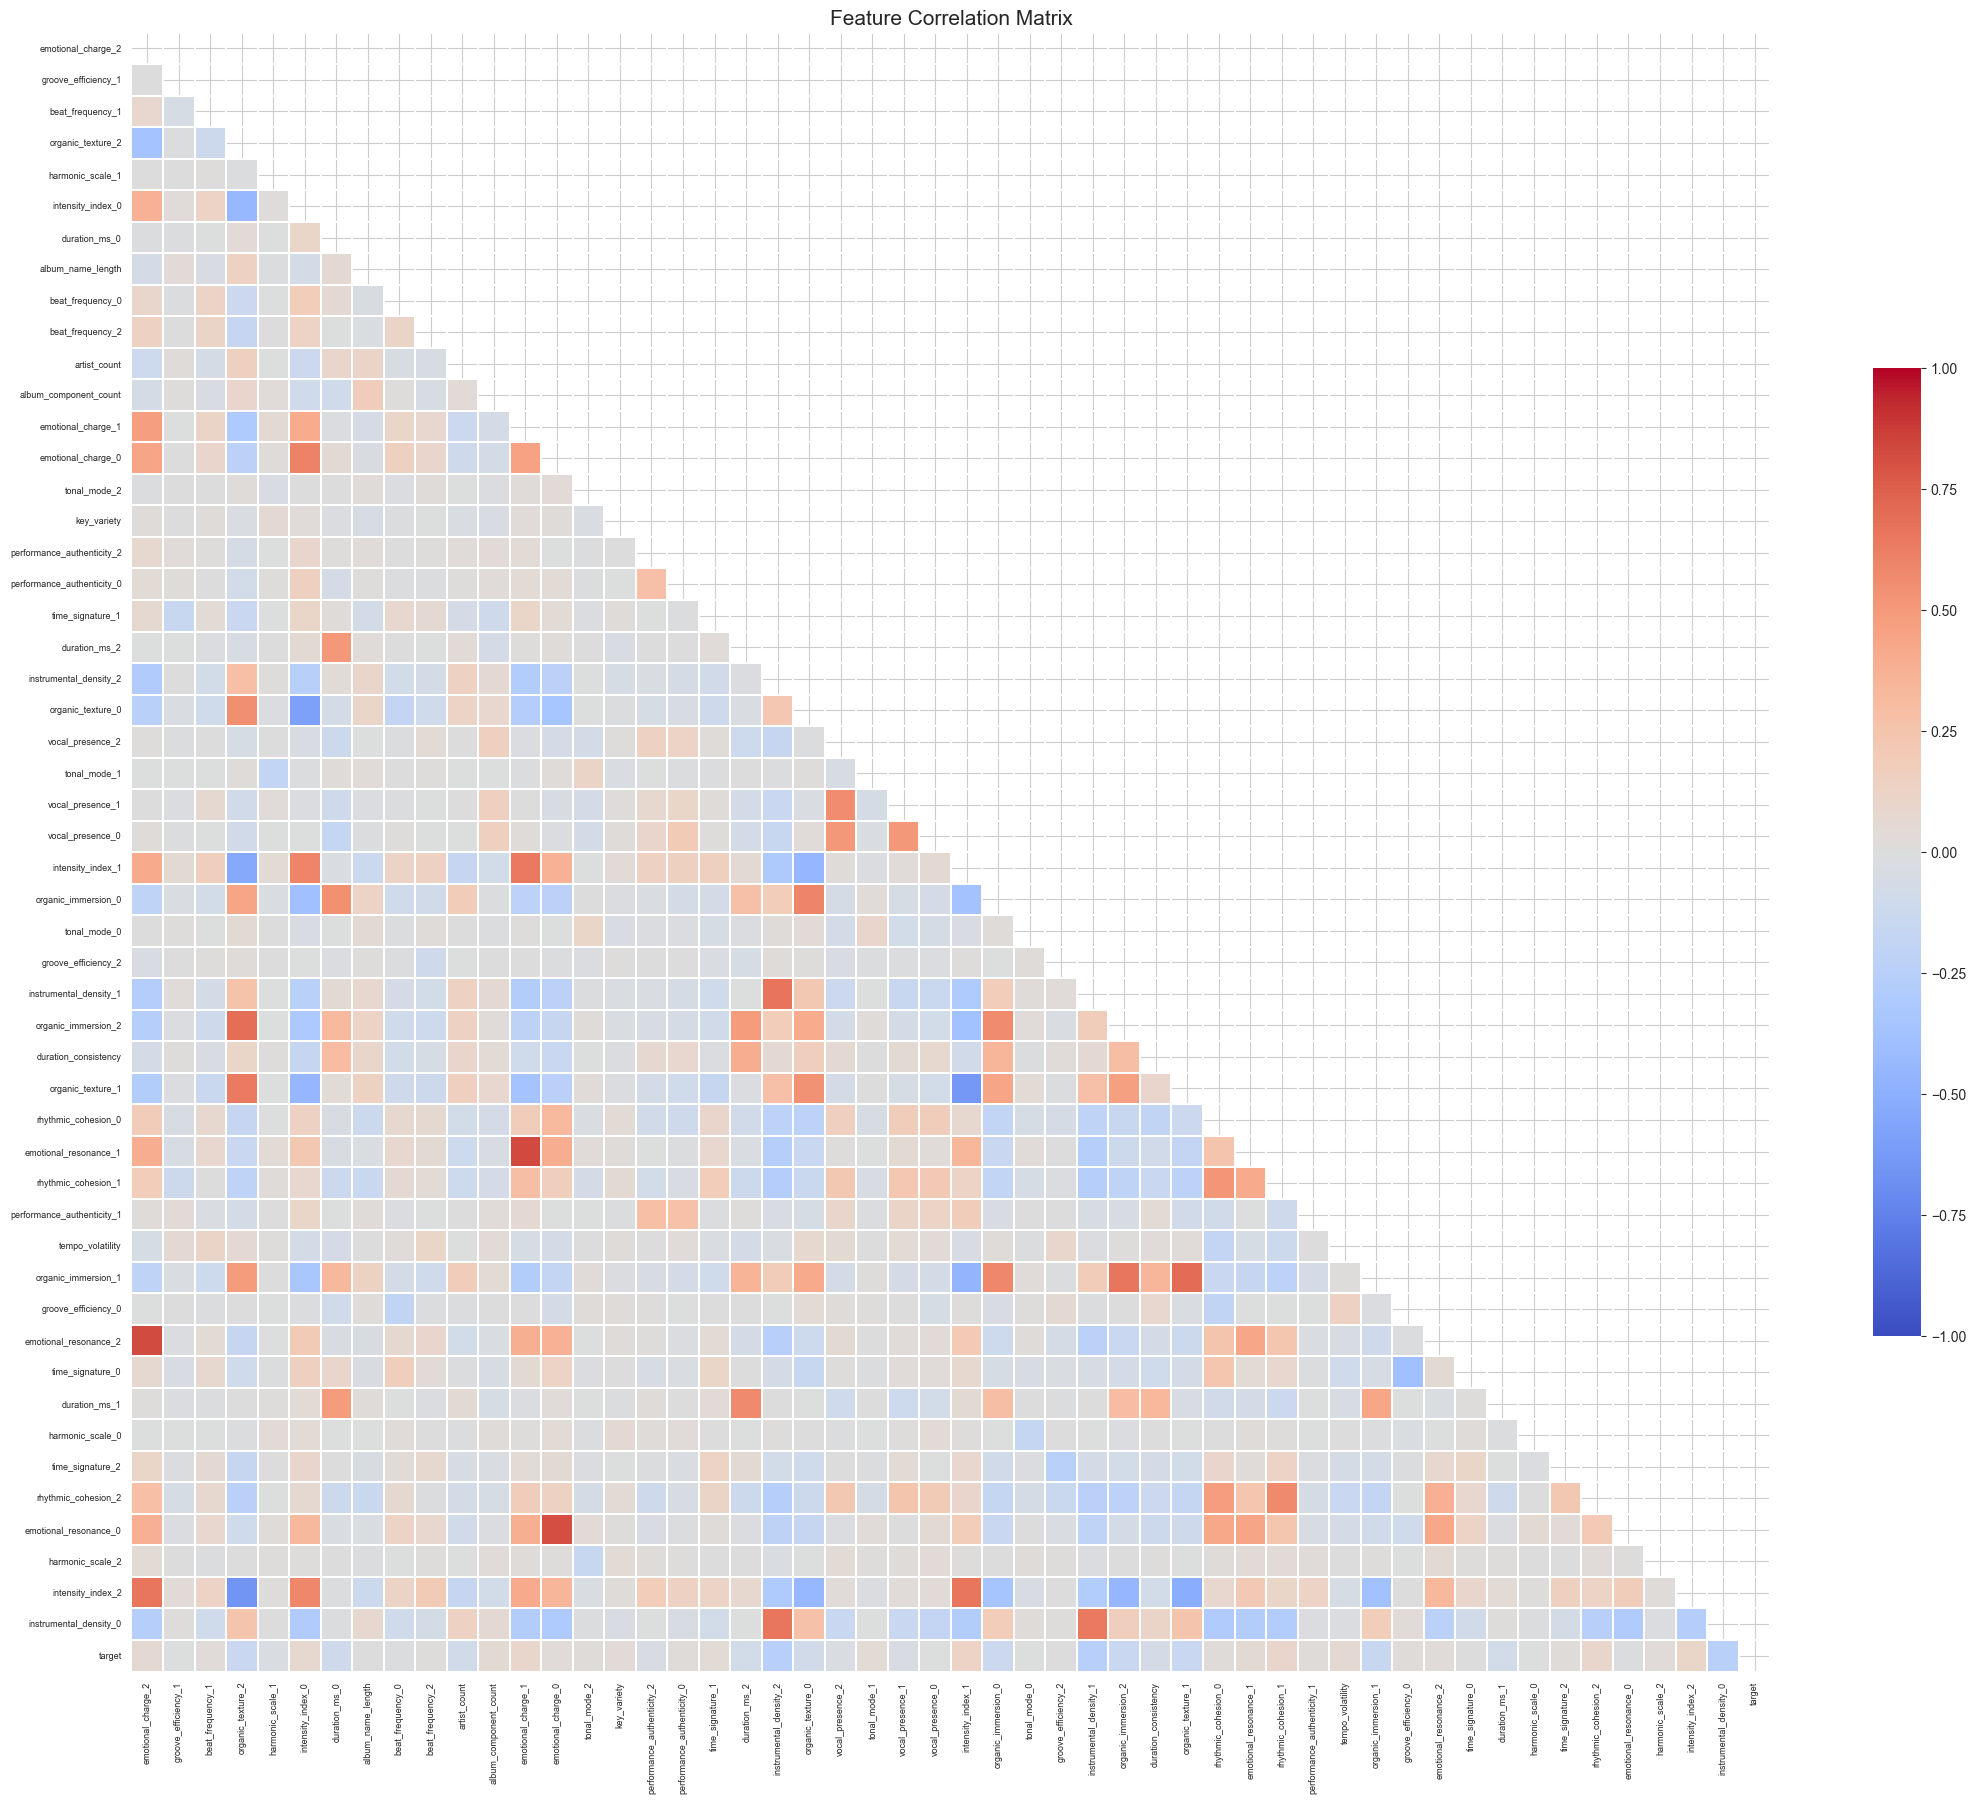

In [28]:
corr_mat = num_prev.corr()

plt.figure(figsize=(22, 20))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat, mask=mask, cmap='coolwarm', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.1,
    cbar_kws={'shrink': 0.5}, annot=False,
    xticklabels=True, yticklabels=True
)
plt.title('Feature Correlation Matrix', fontsize=15)
plt.xticks(rotation=90, fontsize=6.5)
plt.yticks(rotation=0, fontsize=6.5)
plt.tight_layout()
plt.show()

In [78]:
CORR_THRESHOLD = 0.8
cols = corr_mat.columns.tolist()
pairs = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = corr_mat.iloc[i, j]
        if abs(v) >= CORR_THRESHOLD:
            pairs.append((cols[i], cols[j], round(v, 4)))
hcdf = (pd.DataFrame(pairs, columns=['Feature A', 'Feature B', 'Correlation'])
          .sort_values('Correlation', key=abs, ascending=False)
          .reset_index(drop=True))
print(f'Pairs with |r| >= {CORR_THRESHOLD}  ({len(hcdf)} found):')
print(hcdf.to_string())

Pairs with |r| >= 0.8  (3 found):
            Feature A              Feature B  Correlation
0  emotional_charge_1  emotional_resonance_1       0.8327
1  emotional_charge_2  emotional_resonance_2       0.8241
2  emotional_charge_0  emotional_resonance_0       0.8169


drop columns

In [79]:
drops = [
    'emotional_charge_1' ,'emotional_resonance_2','emotional_charge_0'
]
id_cols = [
    'composition_label_0', 'composition_label_1', 'composition_label_2',
    'track_identifier', 'creator_collective'
]
def dropcolumns(df):
    return df.drop(columns= id_cols + drops)

train = dropcolumns(train)
test  = dropcolumns(test)

In [80]:
train = train.drop_duplicates().reset_index(drop=True)

num_cols = train.select_dtypes(include=['float64', 'int64']).columns.drop('target', errors='ignore')
cat_cols = train.select_dtypes(include=['object', 'string']).columns.tolist()

train[num_cols] = train[num_cols].fillna(train[num_cols].mean())
common_num_cols = [c for c in num_cols if c in test.columns]
test[common_num_cols] = test[common_num_cols].fillna(train[common_num_cols].mean())

for col in cat_cols:
    mode = train[col].mode(dropna=True)
    fill_val = mode.iloc[0] if not mode.empty else 'missing'
    train[col] = train[col].fillna(fill_val)
    if col in test.columns:
        test[col] = test[col].fillna(fill_val)

def process_dates(df):
    df = df.copy()
    if 'publication_timestamp' in df.columns:
        df['publication_timestamp'] = pd.to_datetime(df['publication_timestamp'], errors='coerce')
        df['year'] = df['publication_timestamp'].dt.year
        df['month'] = df['publication_timestamp'].dt.month
        df['day'] = df['publication_timestamp'].dt.day
        df['dayofweek'] = df['publication_timestamp'].dt.dayofweek
        df = df.drop(columns=['publication_timestamp'])
    return df

train = process_dates(train)
test = process_dates(test)

print(f'{train.shape}, test: {test.shape}')

(61609, 57), test: (41074, 56)


In [66]:
# Feature Engineering
def eng_features(df):
    bases = [
        'duration_ms', 'intensity_index', 'organic_texture', 'vocal_presence',
        'groove_efficiency', 'emotional_charge', 'emotional_resonance',
        'performance_authenticity', 'instrumental_density', 'beat_frequency',
        'rhythmic_cohesion', 'organic_immersion'
    ]

    for base in bases:
        cols = [f"{base}_{i}" for i in range(3) if f"{base}_{i}" in df.columns]
        if len(cols) >= 2:
            df[f"{base}_avg"] = df[cols].mean(axis=1)
            df[f"{base}_var"] = df[cols].var(axis=1)

    if 'duration_ms_avg' in df.columns and 'intensity_index_avg' in df.columns:
        df['duration_x_intensity'] = df['duration_ms_avg'] * df['intensity_index_avg']
    if 'organic_texture_avg' in df.columns and 'groove_efficiency_avg' in df.columns:
        df['texture_x_groove'] = df['organic_texture_avg'] * df['groove_efficiency_avg']

    return df

train = eng_features(train)
test = eng_features(test)

date-time format

In [ ]:
CAT_COLS = ['weekday_of_release', 'season_of_release', 'lunar_phase']

def engineer(df):
    df = df.copy()
    
    if 'year' in df.columns and 'release_year' not in df.columns:
        df['release_year'] = pd.to_numeric(df['year'], errors='coerce').astype('float32')
    if 'month' in df.columns and 'release_month' not in df.columns:
        df['release_month'] = pd.to_numeric(df['month'], errors='coerce').astype('float32')
    if 'day' in df.columns and 'release_day' not in df.columns:
        df['release_day'] = pd.to_numeric(df['day'], errors='coerce').astype('float32')
    if 'dayofweek' in df.columns and 'release_dayofweek' not in df.columns:
        df['release_dayofweek'] = pd.to_numeric(df['dayofweek'], errors='coerce').astype('float32')

    return df

train_fe = engineer(train)
test_fe = engineer(test)

X_train = train_fe.drop(columns=['target', 'id'], errors='ignore')
y_train = train_fe['target'].astype(float)
X_test = test_fe.drop(columns=['target', 'id'], errors='ignore')
test_ids = test_fe['id']
NUM_COLS = [c for c in X_train.columns if c not in CAT_COLS]

print(f'Numerical   : {len(NUM_COLS)}')
print(f'Categorical : {len(CAT_COLS)}')
print(f'X_train     : {X_train.shape}')

Numerical   : 80
Categorical : 3
X_train     : (61609, 83)


In [68]:
X_train .columns.astype(str)

Index(['emotional_charge_2', 'groove_efficiency_1', 'beat_frequency_1',
       'organic_texture_2', 'harmonic_scale_1', 'intensity_index_0',
       'duration_ms_0', 'album_name_length', 'beat_frequency_0',
       'beat_frequency_2', 'artist_count', 'weekday_of_release',
       'album_component_count', 'tonal_mode_2', 'key_variety',
       'performance_authenticity_2', 'performance_authenticity_0',
       'season_of_release', 'time_signature_1', 'duration_ms_2', 'lunar_phase',
       'instrumental_density_2', 'organic_texture_0', 'vocal_presence_2',
       'tonal_mode_1', 'vocal_presence_1', 'vocal_presence_0',
       'intensity_index_1', 'organic_immersion_0', 'tonal_mode_0',
       'groove_efficiency_2', 'instrumental_density_1', 'organic_immersion_2',
       'duration_consistency', 'organic_texture_1', 'rhythmic_cohesion_0',
       'emotional_resonance_1', 'rhythmic_cohesion_1',
       'performance_authenticity_1', 'tempo_volatility', 'organic_immersion_1',
       'groove_efficiency_

In [69]:
X_train.to_csv('X_train_prepared.csv', index=False)
y_train.to_csv('y_train.csv',index=False)
X_test.to_csv('X_test_prepared.csv',index=False)
test_ids.to_csv('test_ids.csv',index=False)
print('Saved: X_train_prepared.csv  y_train.csv  X_test_prepared.csv  test_ids.csv')


Saved: X_train_prepared.csv  y_train.csv  X_test_prepared.csv  test_ids.csv
